# Calibration 03 — 7 Age-Group Joint Fit

**7 개 연령 그룹 동시 fit**:
- 그룹: `0`, `1-6`, `7-12`, `13-18`, `19-49`, `50-64`, `65+`
- NLL_total = Σ Poisson NLL_{age_group} (7 항 합산)
- 시즌성 β(t), first-peak masking, initial_immunity 통합 적용

**예상 실행 시간**: NLL 평가 비용 7배 + 2000 evals → **60-90분**.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from kt_data import ILI_AGE_GROUPS
from kt_epimodel.calibration.ili_target import (
    load_ili_target_by_age, simulation_to_ili_by_age,
)
from kt_epimodel.calibration.optimizer import (
    optimize_calibration_by_age, save_result, load_result,
)
from kt_epimodel.calibration.simple_model import (
    build_aggregated_inputs, simulate_aggregated,
)
from kt_epimodel.model.compartments import IDX_S
from kt_epimodel.model.parameters import (
    DiseaseParameters, ModelParameters,
)

OUT = Path('../outputs/calibration'); OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. 7 연령 그룹 ILI target 확인

age groups: ['0', '1-6', '7-12', '13-18', '19-49', '50-64', '65+']
n_weeks: 52


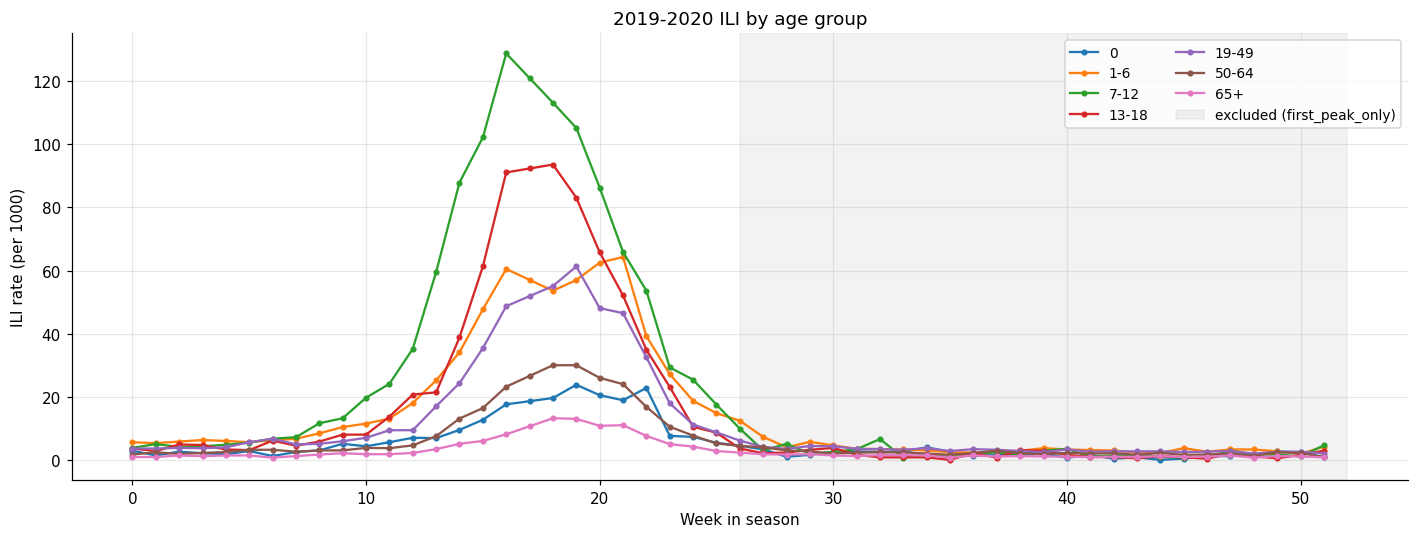

In [2]:
target_age = load_ili_target_by_age('2019-2020', first_peak_only=True, first_peak_end_week=26)
print(f"age groups: {target_age['age_groups']}")
print(f"n_weeks: {target_age['n_weeks']}")

fig, ax = plt.subplots(figsize=(13, 5))
weeks = target_age['week_in_season']
for ag in ILI_AGE_GROUPS:
    ax.plot(weeks, target_age['ili_rates'][ag], 'o-', markersize=3, label=ag)
ax.axvspan(26, 52, alpha=0.1, color='gray', label='excluded (first_peak_only)')
ax.set_xlabel('Week in season'); ax.set_ylabel('ILI rate (per 1000)')
ax.set_title('2019-2020 ILI by age group')
ax.legend(loc='upper right', fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / '2019-2020_target_by_age.png', dpi=120)
plt.show()

## 2. Nelder-Mead 본격 fit

7 그룹 동시 — 평가 비용 7배. max_iter=2000 → 약 60-90분.

In [8]:
t0 = time.time()
result_age = optimize_calibration_by_age(
    season='2019-2020',
    use_data_seed=True,
    gamma_report_assumed=2.0,
    seed_e_factor=0.5,
    initial_immunity=0.3,
    method='Nelder-Mead',
    max_iterations=2000,
    first_peak_only=True,
    first_peak_end_week=26,
    t_span=(0.0, 364.0),
    verbose=True,
)
print(f"\nTotal elapsed: {(time.time() - t0) / 60:.1f} min")
save_result(result_age, OUT / '2019-2020_by_age_NM.json')

Estimated seed by age (γ_report_assumed=2.0, total=38,368):
  age 0-4: 1,805
  age 5-9: 2,525
  age 10-14: 2,400
  age 15-19: 2,201
  age 20-24: 2,808
  age 25-29: 3,594
  age 30-34: 3,482
  age 35-39: 3,316
  age 40-44: 3,912
  age 45-49: 3,814
  age 50-54: 2,304
  age 55-59: 1,996
  age 60-64: 2,003
  age 65-69: 791
  age 70-99: 1,416
=== Optimizing 2019-2020 (by_age, 7 groups) with Nelder-Mead ===
Initial NLL: 2505.46
[Eval   10] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.700  NLL=1984.90
[Eval   20] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.700  NLL=2486.83
[Eval   30] β=(0.050,0.050,0.050,0.050) γ_r=0.505 amp=0.707  NLL=1599.74
[Eval   40] β=(0.051,0.050,0.051,0.051) γ_r=0.479 amp=0.713  NLL=1005.81
[Eval   50] β=(0.051,0.050,0.051,0.051) γ_r=0.504 amp=0.707  NLL=727.75
[Eval   60] β=(0.051,0.049,0.052,0.051) γ_r=0.502 amp=0.706  NLL=341.94
[Eval   70] β=(0.051,0.050,0.052,0.051) γ_r=0.496 amp=0.709  NLL=-53.03
[Eval   80] β=(0.051,0.049,0.053,0.053) γ_r=0.499 amp=0.710  NLL=-5

/Users/hwcho/Documents/python/NIMS/kt_epimodel/src/kt_epimodel/calibration/optimizer.py:251: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(


## 2b. L-BFGS-B 빠른 fit (gradient-based)

22D 공간에서 Nelder-Mead 는 느림. L-BFGS-B 로 gradient 정보 활용해 빠른 수렴 시도.

**예상 시간**: 30-60분 (Nelder-Mead 의 절반 이하).

In [3]:
import time

t0 = time.time()
result_age_lbfgs = optimize_calibration_by_age(
    season='2019-2020',
    use_data_seed=True,
    gamma_report_assumed=2.0,
    seed_e_factor=0.5,
    initial_immunity=0.3,
    method='L-BFGS-B',
    max_iterations=500,
    first_peak_only=True,
    first_peak_end_week=26,
    t_span=(0.0, 364.0),
    verbose=True,
)
print(f"\nTotal elapsed: {(time.time() - t0) / 60:.1f} min")
save_result(result_age_lbfgs, OUT / '2019-2020_by_age_LBFGS.json')

Estimated seed by age (γ_report_assumed=2.0, total=38,368):
  age 0-4: 1,805
  age 5-9: 2,525
  age 10-14: 2,400
  age 15-19: 2,201
  age 20-24: 2,808
  age 25-29: 3,594
  age 30-34: 3,482
  age 35-39: 3,316
  age 40-44: 3,912
  age 45-49: 3,814
  age 50-54: 2,304
  age 55-59: 1,996
  age 60-64: 2,003
  age 65-69: 791
  age 70-99: 1,416
=== Optimizing 2019-2020 (by_age, 7 groups) with L-BFGS-B ===
Initial NLL: 9283.78
[Eval   10] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=1.000 base=0.100 σ=40.0  NLL=9283.78
[Eval   20] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=1.000 base=0.100 σ=40.0  NLL=9283.78
[Eval   30] β=(0.001,0.001,0.001,0.001) γ_r=1.000 amp=0.000 base=1.000 σ=15.0  NLL=7577.08
[Eval   40] β=(0.001,0.001,0.001,0.001) γ_r=1.000 amp=0.000 base=1.000 σ=15.0  NLL=7577.08
[Eval   50] β=(0.045,0.023,0.003,0.054) γ_r=1.000 amp=0.000 base=1.000 σ=15.0  NLL=7644.26
[Eval   60] β=(0.045,0.023,0.003,0.054) γ_r=1.000 amp=0.000 base=1.000 σ=15.0  NLL=7644.26
[Eval   70] β=(0.045,0.023,0.003

In [ ]:
print("=== Method 비교 ===")
print(f"{'Method':<15} {'NLL':>12} {'Evals':>8} {'Min':>6}")
print(f"{'Nelder-Mead':<15} {result_age.nll:>12.2f} {result_age.n_evaluations:>8} {result_age.elapsed_seconds/60:>6.1f}")
print(f"{'L-BFGS-B':<15} {result_age_lbfgs.nll:>12.2f} {result_age_lbfgs.n_evaluations:>8} {result_age_lbfgs.elapsed_seconds/60:>6.1f}")

print(f"\n=== 핵심 파라미터 ===")
print(f"{'Param':<14} {'NM':>10} {'L-BFGS-B':>10}")
for name, v_nm, v_lb in [
    ('beta_h',        result_age.calibration.beta_h,      result_age_lbfgs.calibration.beta_h),
    ('beta_w',        result_age.calibration.beta_w,      result_age_lbfgs.calibration.beta_w),
    ('beta_s',        result_age.calibration.beta_s,      result_age_lbfgs.calibration.beta_s),
    ('beta_o',        result_age.calibration.beta_o,      result_age_lbfgs.calibration.beta_o),
    ('gamma_report',  result_age.calibration.gamma_report, result_age_lbfgs.calibration.gamma_report),
    ('seasonality_amp',  result_age.seasonality_amp,  result_age_lbfgs.seasonality_amp),
    ('seasonality_base', result_age.seasonality_base, result_age_lbfgs.seasonality_base),
    ('seasonality_sigma',result_age.seasonality_sigma,result_age_lbfgs.seasonality_sigma),
]:
    print(f"{name:<14} {v_nm:>10.4f} {v_lb:>10.4f}")

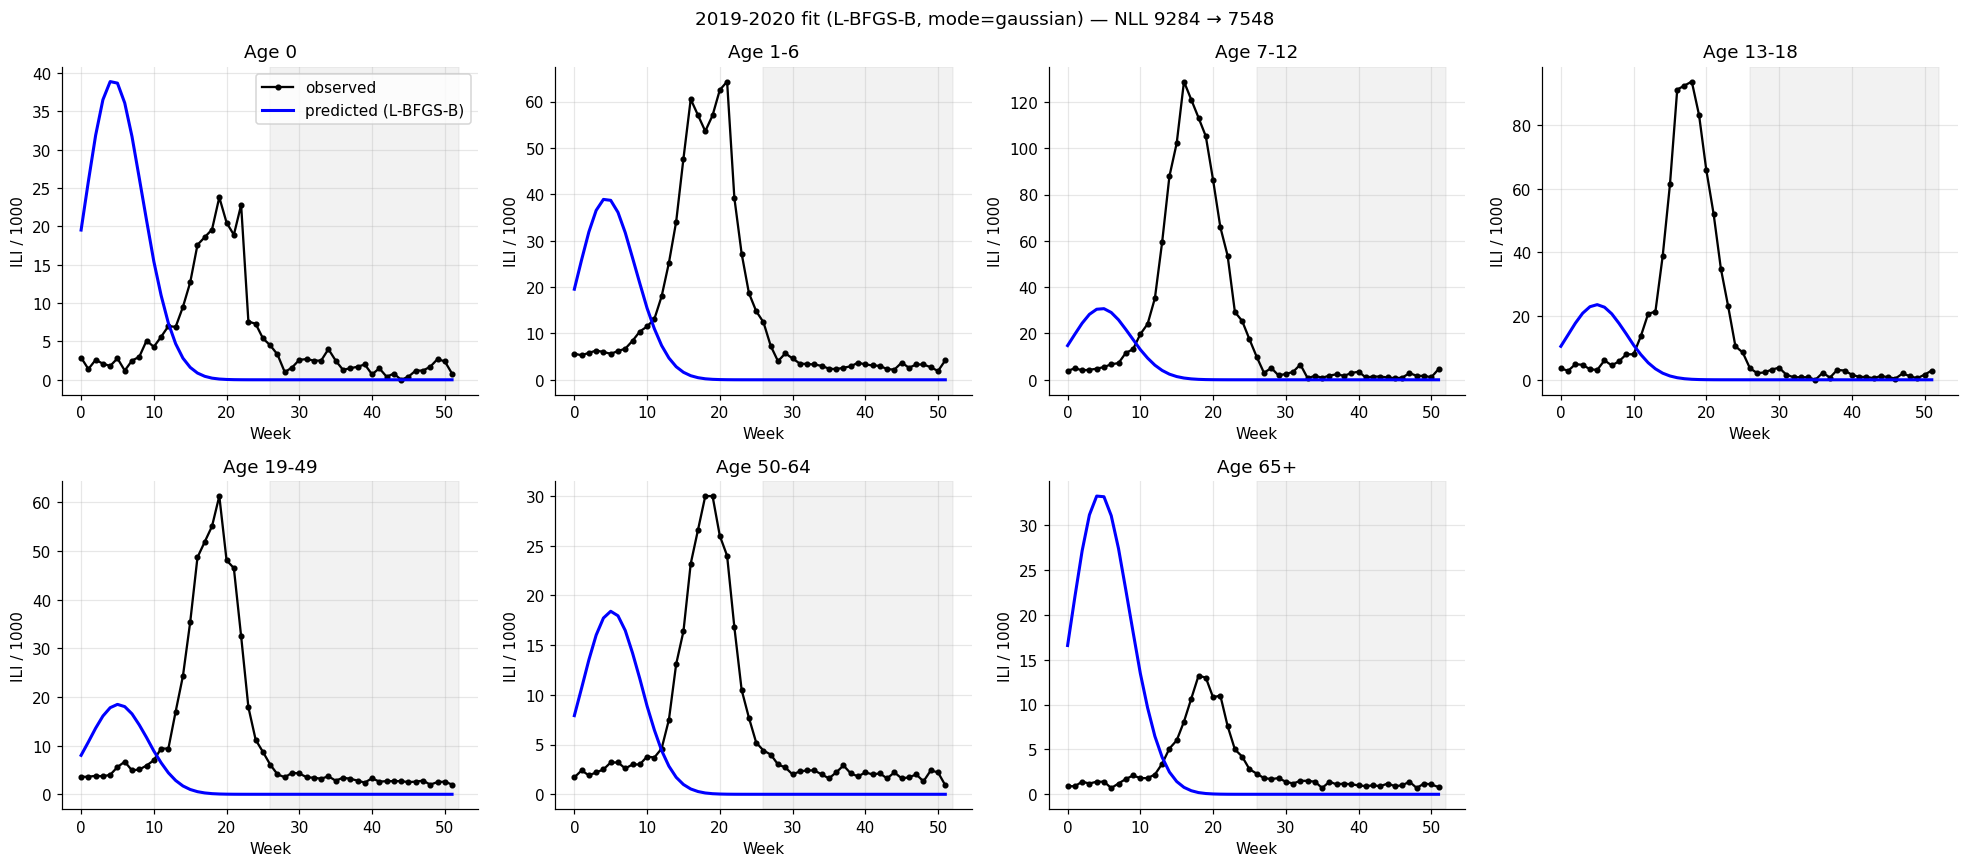

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from kt_epimodel.calibration.simple_model import (
    simulate_aggregated, build_aggregated_inputs, estimate_initial_infected_from_ili,
)
from kt_epimodel.calibration.ili_target import (
    simulation_to_ili_by_age, load_ili_target_by_age,
)
from kt_epimodel.model.parameters import ModelParameters, DiseaseParameters

inputs = build_aggregated_inputs()
result = result_age_lbfgs    # L-BFGS-B fit 결과 사용

disease = DiseaseParameters(
    seasonality_mode=result.seasonality_mode,
    seasonality_amp=result.seasonality_amp,
    seasonality_base=result.seasonality_base,
    seasonality_sigma=result.seasonality_sigma,
    seasonality_peak_day=result.seasonality_peak_day,
)
params = ModelParameters(disease=disease, calibration=result.calibration)

seed = estimate_initial_infected_from_ili(
    '2019-2020', inputs['pop_15'].flatten(),
    gamma_report_assumed=result.gamma_report_assumed,
)
sim = simulate_aggregated(
    params, inputs,
    seed_by_age=seed,
    seed_e_factor=0.5,
    initial_immunity=result.initial_immunity,
    t_span=(0, 364),
)
S = sim.states[:, 0, :, :].sum(axis=-1)
daily_inc = -np.diff(S, axis=0)
predictions_lbfgs = simulation_to_ili_by_age(
    daily_inc, inputs['pop_15'].flatten(),
    result.calibration.gamma_report, n_weeks=52,
)

target = load_ili_target_by_age('2019-2020', first_peak_only=True, first_peak_end_week=26)
age_groups = ['0', '1-6', '7-12', '13-18', '19-49', '50-64', '65+']
weeks_arr = np.arange(52)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, ag in enumerate(age_groups):
    ax = axes[i]
    ax.plot(weeks_arr, target['ili_rates'][ag], 'ko-', markersize=3, label='observed')
    ax.plot(weeks_arr, predictions_lbfgs[ag], 'b-', linewidth=2, label='predicted (L-BFGS-B)')
    ax.axvspan(26, 52, alpha=0.1, color='gray')
    ax.set_title(f'Age {ag}')
    ax.set_xlabel('Week'); ax.set_ylabel('ILI / 1000')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()
axes[-1].axis('off')
fig.suptitle(
    f"2019-2020 fit (L-BFGS-B, mode={result.seasonality_mode}) — "
    f"NLL {result.nll_initial:.0f} → {result.nll:.0f}"
)
fig.tight_layout()
fig.savefig(OUT / '2019-2020_by_age_LBFGS_fit.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Fit 결과 — 7 연령 그룹 관측 vs 예측

In [ ]:
from kt_epimodel.calibration.simple_model import estimate_initial_infected_from_ili

inputs = build_aggregated_inputs()
pop_15 = inputs['pop_15'].flatten()

# fit 결과 reproduce: 같은 seasonality (mode/amp/base/sigma) + seed/immunity 사용
disease = DiseaseParameters(
    seasonality_mode=result_age.seasonality_mode,
    seasonality_amp=result_age.seasonality_amp,
    seasonality_base=result_age.seasonality_base,
    seasonality_sigma=result_age.seasonality_sigma,
    seasonality_peak_day=result_age.seasonality_peak_day,
)
params = ModelParameters(disease=disease).with_calibration(result_age.calibration)

if result_age.use_data_seed:
    seed_by_age = estimate_initial_infected_from_ili(
        '2019-2020', pop_15,
        gamma_report_assumed=result_age.gamma_report_assumed,
    )
else:
    seed_by_age = None

sim = simulate_aggregated(
    params, inputs,
    seed_total=result_age.seed_total if not result_age.use_data_seed else 0.0,
    seed_by_age=seed_by_age,
    initial_immunity=result_age.initial_immunity,
    t_span=(0.0, 364.0),
)
S_age = sim.states[:, IDX_S, :, :].sum(axis=-1)        # (n_t, 15)
daily_inc = -np.diff(S_age, axis=0)                    # (n_t-1, 15)
predictions = simulation_to_ili_by_age(
    daily_inc, pop_15, result_age.calibration.gamma_report, n_weeks=52,
)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for i, ag in enumerate(ILI_AGE_GROUPS):
    ax = axes[i // 4, i % 4]
    ax.plot(weeks, target_age['ili_rates'][ag], 'ko-', markersize=3, label='observed')
    ax.plot(weeks, predictions[ag], 'r-', linewidth=2, label='predicted')
    ax.axvspan(26, 52, alpha=0.1, color='gray')
    ax.set_title(f'Age {ag}')
    ax.grid(True, alpha=0.3)
    if i % 4 == 0:
        ax.set_ylabel('ILI / 1000')
    if i // 4 == 1:
        ax.set_xlabel('Week')
axes[1, 3].axis('off')
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle(
    f'2019-2020 fit by age (mode={result_age.seasonality_mode}) — '
    f'NLL {result_age.nll_initial:.0f} → {result_age.nll:.0f}',
    fontsize=13,
)
plt.tight_layout()
plt.savefig(OUT / '2019-2020_by_age_fit.png', dpi=120)
plt.show()

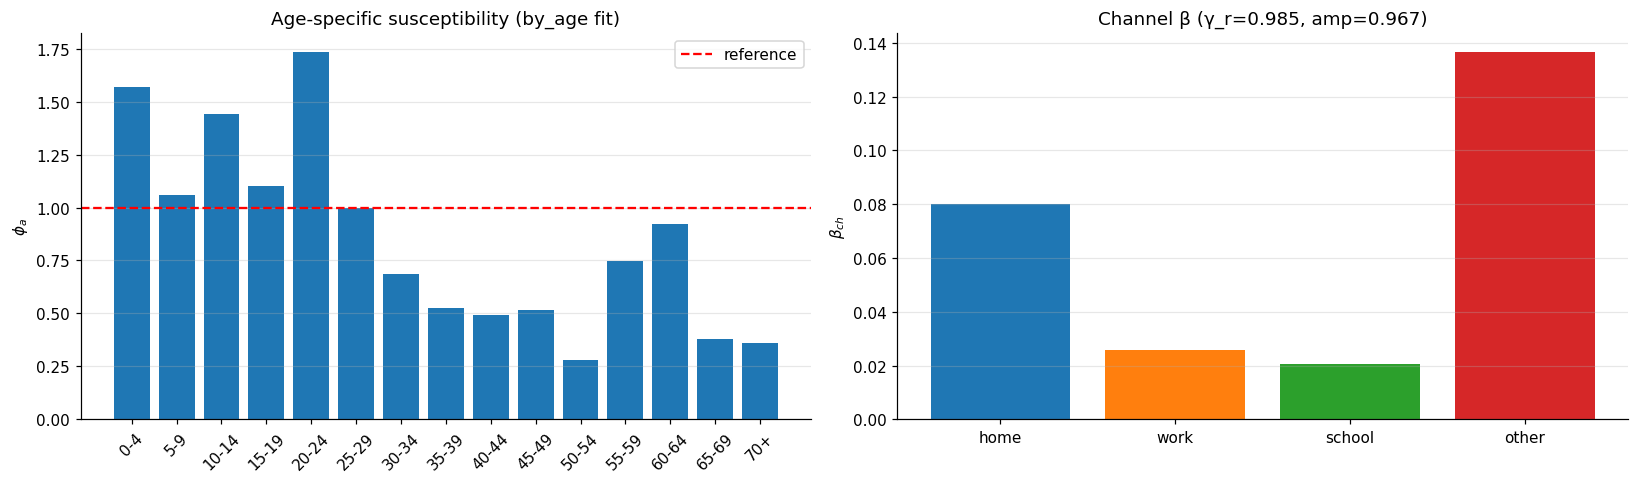

shape: (1, 13)
┌────────────┬────────────┬────────────┬─────────┬───┬────────────┬───────────┬─────────┬──────────┐
│ season     ┆ nll_initia ┆ nll_final  ┆ n_evals ┆ … ┆ gamma_repo ┆ seasonali ┆ phi_min ┆ phi_max  │
│ ---        ┆ l          ┆ ---        ┆ ---     ┆   ┆ rt         ┆ ty_amp    ┆ ---     ┆ ---      │
│ str        ┆ ---        ┆ f64        ┆ i64     ┆   ┆ ---        ┆ ---       ┆ f64     ┆ f64      │
│            ┆ f64        ┆            ┆         ┆   ┆ f64        ┆ f64       ┆         ┆          │
╞════════════╪════════════╪════════════╪═════════╪═══╪════════════╪═══════════╪═════════╪══════════╡
│ 2019-2020_ ┆ 2505.45782 ┆ -8050.1453 ┆ 2565    ┆ … ┆ 0.984822   ┆ 0.966625  ┆ 0.28088 ┆ 1.736381 │
│ by_age     ┆            ┆ 34         ┆         ┆   ┆            ┆           ┆         ┆          │
└────────────┴────────────┴────────────┴─────────┴───┴────────────┴───────────┴─────────┴──────────┘


In [5]:
# φ_a + β + 요약
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
AGES = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
        '40-44','45-49','50-54','55-59','60-64','65-69','70+']
axes[0].bar(np.arange(15), result_age.calibration.phi)
axes[0].axhline(1.0, color='red', linestyle='--', label='reference')
axes[0].set_xticks(np.arange(15)); axes[0].set_xticklabels(AGES, rotation=45)
axes[0].set_ylabel(r'$\phi_a$')
axes[0].set_title('Age-specific susceptibility (by_age fit)')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

channels = ['home', 'work', 'school', 'other']
betas = [result_age.calibration.beta_h, result_age.calibration.beta_w,
         result_age.calibration.beta_s, result_age.calibration.beta_o]
axes[1].bar(channels, betas, color=['C0', 'C1', 'C2', 'C3'])
axes[1].set_ylabel(r'$\beta_{ch}$')
axes[1].set_title(f'Channel β (γ_r={result_age.calibration.gamma_report:.3f}, amp={result_age.seasonality_amp:.3f})')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT / '2019-2020_by_age_phi_beta.png', dpi=120)
plt.show()

print(pl.DataFrame([{
    'season': result_age.season,
    'nll_initial': result_age.nll_initial,
    'nll_final': result_age.nll,
    'n_evals': result_age.n_evaluations,
    'elapsed_min': result_age.elapsed_seconds / 60,
    'beta_h': result_age.calibration.beta_h,
    'beta_w': result_age.calibration.beta_w,
    'beta_s': result_age.calibration.beta_s,
    'beta_o': result_age.calibration.beta_o,
    'gamma_report': result_age.calibration.gamma_report,
    'seasonality_amp': result_age.seasonality_amp,
    'phi_min': float(result_age.calibration.phi.min()),
    'phi_max': float(result_age.calibration.phi.max()),
}]))

## 4. Holdout — 2022-2023 예측 (다른 시즌)

2019-2020 fit 그대로 적용해 2022-2023 7 그룹 시계열 예측.

In [ ]:
target_2223 = load_ili_target_by_age('2022-2023', first_peak_only=True)
# 이미 sim 변수 → 동일 파라미터로 시즌 무관 (시즌 시작 기준만 변동)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for i, ag in enumerate(ILI_AGE_GROUPS):
    ax = axes[i // 4, i % 4]
    ax.plot(weeks, target_2223['ili_rates'][ag], 'ko-', markersize=3, label='observed 22-23')
    ax.plot(weeks, predictions[ag], 'r-', linewidth=2, label='predicted (19-20 fit)')
    ax.axvspan(26, 52, alpha=0.1, color='gray')
    ax.set_title(f'Age {ag}')
    ax.grid(True, alpha=0.3)
    if i % 4 == 0:
        ax.set_ylabel('ILI / 1000')
    if i // 4 == 1:
        ax.set_xlabel('Week')
axes[1, 3].axis('off')
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Holdout: 2019-2020 fit → 2022-2023 prediction', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'holdout_by_age_2022-2023.png', dpi=120)
plt.show()

## 결론

**점검 항목**:
- 7 그룹 모두 정성적 fit (peak timing, magnitude order)
- φ_a 합리적 (어린이 (idx 0-3) 높고 노인 (idx 14) 다른 값 — 면역 history 반영)
- seasonality_amp 0.3 ~ 0.7 사이로 수렴
- Holdout 2022-2023 정성 일치 — 다른 시즌이라 정확 fit 기대 X

**다음 단계**:
- 시즌별 calibration (2018-2019, 2022-2023 각각)
- 시즌 간 파라미터 비교 (φ_a 안정성 등)
- ICER Stage 4 — 정책 시나리오 비용효과